# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais (3 axes) et angles (quaternion) d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération (3 axes) et de gyroscopie (3 axes)_
_Date : 2026-04-07_
---


 3
Regrouper ici tous les liens.

https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/04b2bea802321086effbd99402fc13c893d11110/10-Unscented-Kalman-Filter.ipynb

https://www.ferdinandpiette.com/blog/2011/04/exemple-dutilisation-du-filtre-de-kalman/



## 1. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [1]:
# import math
import matplotlib.pyplot as plt
import numpy as np

from Test_Kalman_8 import Test_Kalman_8_Class_v2 as tk

## 2. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [2]:
# Paramètres globaux

totalTime = 100.0
timeStep = 0.01



## 3. Configuration du modèle

Déclarer ici la configuration du modèle programmé.

In [3]:
# Génération du comportement vrai
simConfig = tk.SimulationConfig(
    totalTime=totalTime,
    timeStep=timeStep,
    trueInitialAlpha=np.deg2rad(-45.0),
    trueInitialAlphadot=np.deg2rad(0.0),
    trueInitialBiasX=np.deg2rad(10.0),
    trueInitialBiasY=np.deg2rad(15.0),
    trueInitialBiasZ=np.deg2rad(20.0),
    measurementAccelNoiseStd=0.2,
    measurementGyroNoiseStd=np.deg2rad(10.0),
)

# trueBiases = np.full(simConfig.sampleSize,[[simConfig.trueInitialBiasX, simConfig.trueInitialBiasY,simConfig.trueInitialBiasZ]])
trueBiases = np.tile(
    [
        simConfig.trueInitialBiasX,
        simConfig.trueInitialBiasY,
        simConfig.trueInitialBiasZ,
    ],
    (simConfig.sampleSize, 1)
)

trueAngularAccel = 0.9
simConfig.setAngularAccelerationProfile(
    [
        [0.0, np.deg2rad(0.0)],
        [.3, np.deg2rad(trueAngularAccel)],
        [.4, np.deg2rad(-trueAngularAccel)],
        [.5, np.deg2rad(0.0)],
        [.6, np.deg2rad(-trueAngularAccel)],
        [.7, np.deg2rad(trueAngularAccel)],
        [.8, np.deg2rad(0.0)],
    ]
)

In [4]:
# Génération des mesures bruitées
(
    timeArray,
    trueAlphaArray,
    trueAlphaDotArray,
    trueQuaternionArray,
    measuredAccelXArray,
    measuredAccelYArray,
    measuredAccelZArray,
    measuredGyroXArray,
    measuredGyroYArray,
    measuredGyroZArray,
) = simConfig.generateTrueValuesAndMeasurements()

TimeStep : 0.01


## 4. Paramétrage et préparation de balayage de valeur

Préparer un paramétrage de référence, de base puis des balayage de valeurs pour 1 paramètre particulier.

In [5]:
# Réglage de référence : réglages par défaut
paramsRef = tk.UkfParams(
    simConfig,
    supposedInitialQuaternion=None,
    supposedInitialBiasX=0.0,
    supposedInitialBiasY=0.0,
    supposedInitialBiasZ=0.0,
    processQuaternionNoiseStd=0.001,
    processBiasNoiseStd=0.001,  # => Q
    processInitialConfidenceStd=1.0,  # => P₀
    label="Référence",
)

In [6]:
# Réglage de base : réalisé par collection des résultats des séries
# À faire évoluer en conservant les meilleures valeurs par étude des courbes suivantes
paramsBase = tk.UkfParams.fromBase(
    paramsRef,
    processQuaternionNoiseStd=0.01,
    processBiasNoiseStd=0.001,  # => Q
    processInitialConfidenceStd=0.1,  # => P₀
    label="Base",
)

In [7]:

# paramsSweep = UkfParams.createSweepParams(
#     paramsBase,
#     "processBiasNoiseStd",
#     [0.001, 0.01, 0.1]
# )

# paramsSweep = UkfParams.createSweepParams(
#     paramsBase,
#     "processQuaternionNoiseStd",
#     [0.001, 0.01, 0.1]
# )

paramsSweep = tk.UkfParams.createSweepParams(
    paramsBase,
    "processInitialConfidenceStd",
    [0.01, 0.1, 1.0]
)



## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [8]:
# Instanciation du filtre de Kalman et de son moteur
ukfModel = tk.UkfModel(simConfig)
runner = tk.UkfRunner()

In [9]:
# Application du filtre sur la série de paramètres
results = []
for currentParams in paramsSweep:
    currentLabel = currentParams.label
    results.append(
        runner.run(
            ukfModel,
            currentParams,
            measuredAccelXArray,
            measuredAccelYArray,
            measuredAccelZArray,
            measuredGyroXArray,
            measuredGyroYArray,
            measuredGyroZArray,
            label=currentLabel
        )
    )


## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

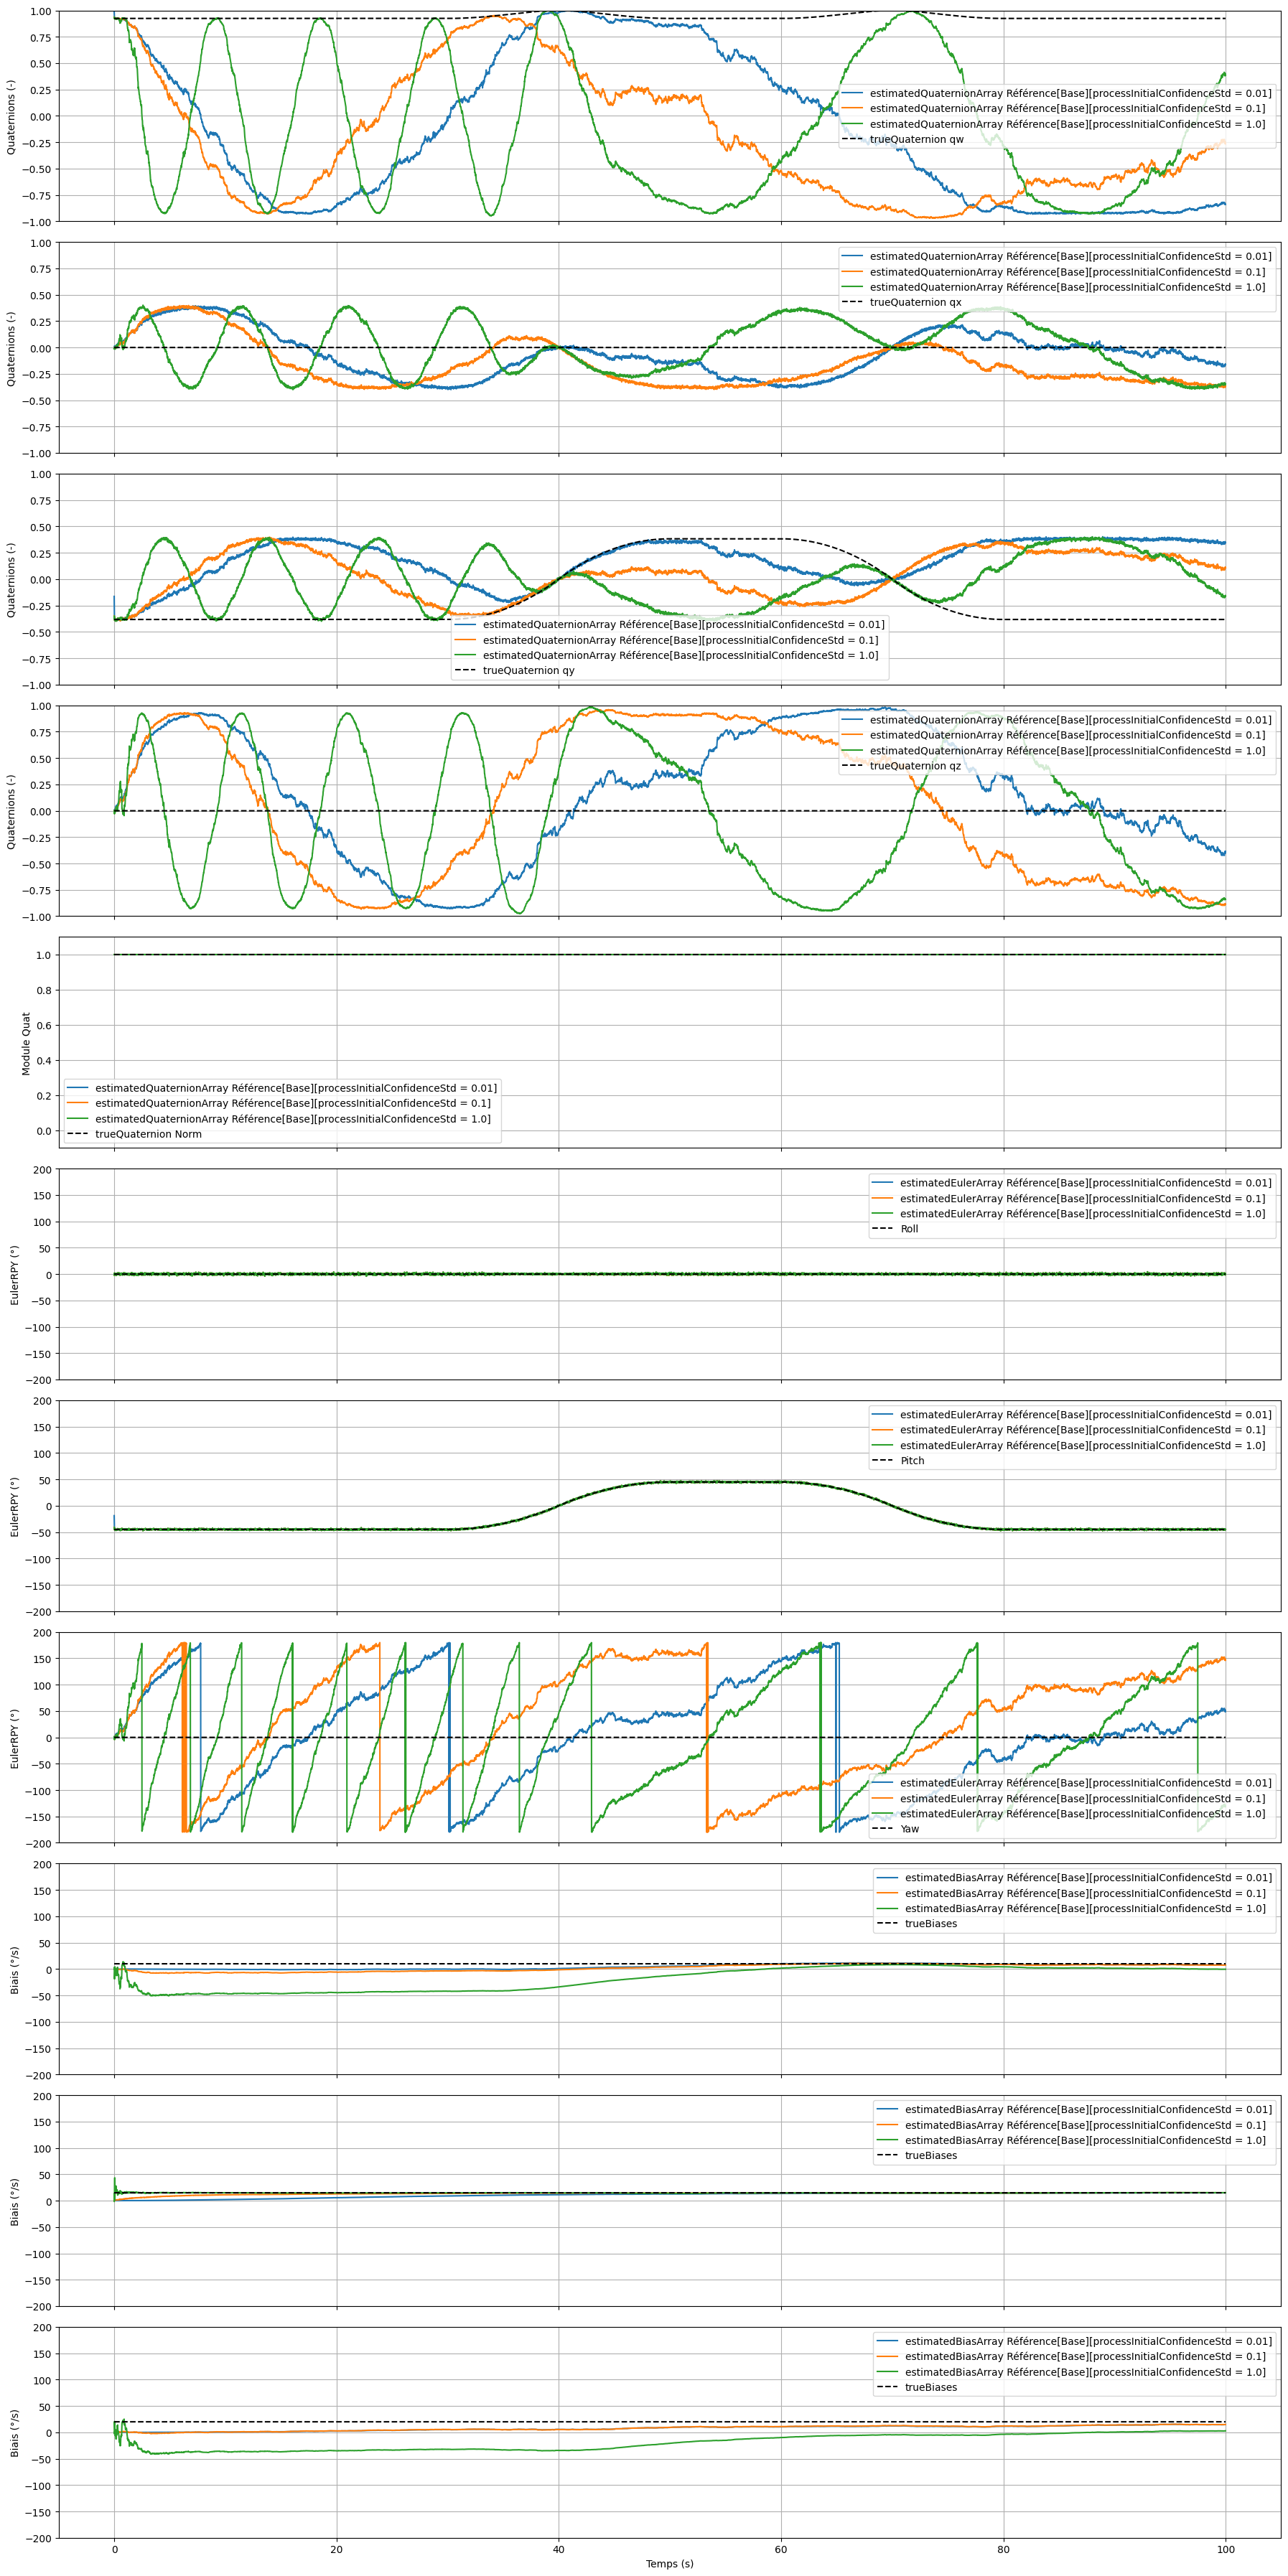

In [10]:
    fig, axes = plt.subplots(11, 1, figsize=(18, 36), sharex=True)
    for res in results:
        axes[0].plot(timeArray, res.estimatedQuaternionArray[:, 0], label="estimatedQuaternionArray " + res.label)
        axes[1].plot(timeArray, res.estimatedQuaternionArray[:, 1], label="estimatedQuaternionArray " + res.label)
        axes[2].plot(timeArray, res.estimatedQuaternionArray[:, 2], label="estimatedQuaternionArray " + res.label)
        axes[3].plot(timeArray, res.estimatedQuaternionArray[:, 3], label="estimatedQuaternionArray " + res.label)
        axes[4].plot(timeArray, np.linalg.norm(res.estimatedQuaternionArray, axis=-1),
                     label="estimatedQuaternionArray " + res.label)
        axes[5].plot(timeArray, np.rad2deg(res.estimatedEulerArray[:, 0]), label="estimatedEulerArray " + res.label)
        axes[6].plot(timeArray, np.rad2deg(res.estimatedEulerArray[:, 1]), label="estimatedEulerArray " + res.label)
        axes[7].plot(timeArray, np.rad2deg(res.estimatedEulerArray[:, 2]), label="estimatedEulerArray " + res.label)
        axes[8].plot(timeArray, np.rad2deg(res.estimatedBiasArray[:, 0]), label="estimatedBiasArray " + res.label)
        axes[9].plot(timeArray, np.rad2deg(res.estimatedBiasArray[:, 1]), label="estimatedBiasArray " + res.label)
        axes[10].plot(timeArray, np.rad2deg(res.estimatedBiasArray[:, 2]), label="estimatedBiasArray " + res.label)

    axes[0].plot(timeArray, trueQuaternionArray[:, 0], 'k--', label="trueQuaternion qw")
    axes[1].plot(timeArray, trueQuaternionArray[:, 1], 'k--', label="trueQuaternion qx")
    axes[2].plot(timeArray, trueQuaternionArray[:, 2], 'k--', label="trueQuaternion qy")
    axes[3].plot(timeArray, trueQuaternionArray[:, 3], 'k--', label="trueQuaternion qz")
    axes[4].plot(timeArray, np.linalg.norm(trueQuaternionArray, axis=-1), 'k--', label="trueQuaternion Norm")

    axes[5].plot(timeArray, np.rad2deg([0] * simConfig.sampleSize), 'k--', label="Roll")
    axes[6].plot(timeArray, np.rad2deg(trueAlphaArray), 'k--', label="Pitch")
    axes[7].plot(timeArray, np.rad2deg([0] * simConfig.sampleSize), 'k--', label="Yaw")
    axes[8].plot(timeArray, np.rad2deg(trueBiases[:, 0]), 'k--', label="trueBiases")
    axes[9].plot(timeArray, np.rad2deg(trueBiases[:, 1]), 'k--', label="trueBiases")
    axes[10].plot(timeArray, np.rad2deg(trueBiases[:, 2]), 'k--', label="trueBiases")

    axes[0].set_ylim(-1.0, 1.0)
    axes[1].set_ylim(-1.0, 1.0)
    axes[2].set_ylim(-1.0, 1.0)
    axes[3].set_ylim(-1.0, 1.0)
    axes[4].set_ylim(-0.1, 1.1)
    axes[5].set_ylim(-200.0, 200.0)
    axes[6].set_ylim(-200.0, 200.0)
    axes[7].set_ylim(-200.0, 200.0)
    axes[8].set_ylim(-200.0, 200.0)
    axes[9].set_ylim(-200.0, 200.0)
    axes[10].set_ylim(-200.0, 200.0)

    # titles = [np.reshape(["Quaternions (-)"]*4, (4,1)), np.reshape(["EulerDeg (°)"]*3, (3,1)), np.reshape(["Biais (°/s)"]*3, (3,1))]
    # titles = np.reshape(titles, (10, 1, 1))
    titles = ["Quaternions (-)"] * 4 + ["Module Quat"] + ["EulerRPY (°)"] * 3 + ["Biais (°/s)"] * 3
    for ax, title in zip(axes, titles):
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True)

    axes[10].set_xlabel("Temps (s)")
    plt.tight_layout()
    plt.show()
